# 4D-STEM DPC - phase gradient and phase reconstruction

## by Dan Durham (2023) with updates by Pravan Chakravarthy (2026)

Calculates phase gradient and magnetic induction from a beam shift `.npy` file (can calculate this with `ECC_DiskTracking` or `CoM_DiskTracking`).

Associated package `dpc4dstem` must be installed. Other dependencies include: `matplotlib`, `numpy`, `scipy`, `scikit-image`, `ncempy`

In [15]:
# %load_ext autoreload
# %autoreload 2

import numpy as np
import matplotlib.pyplot as plt
import matplotlib

import dpc4dstem as dpc4d
import PyLorentz

from skimage import filters
from scipy.ndimage import gaussian_filter, median_filter

%matplotlib inline

In [16]:
plt.style.use('seaborn-v0_8-poster')

In [46]:
sample_name = '_rectangle'
sample_shape = sample_name[:5]
analysis_tag = 'ECC'
shift_map = np.load('output/'+analysis_tag+sample_shape+'_shift_map.npy')
print(shift_map.shape)
R_Ny,R_Nx,_ = shift_map.shape
Rx,Ry = np.meshgrid(np.arange(R_Nx),np.arange(R_Ny))

(99, 157, 2)


In [47]:
# Input parameters
if sample_name == '_disk':
    nm_per_px = 40.04 #nm
    R0 = 97.61
elif sample_name == '_rectangle':
    nm_per_px = 28.31 #nm
    R0 = 97.56
lamb_elec = 0.00251 #nm
alpha = 200 #urad (Convergence (semi)angle)
rot_theta = 32.9*(np.pi/180) # rad (rotation between Rx,Ry and Qx,Qy planes)

urad_per_px = alpha/R0

print(nm_per_px)

28.31


### Remove descan

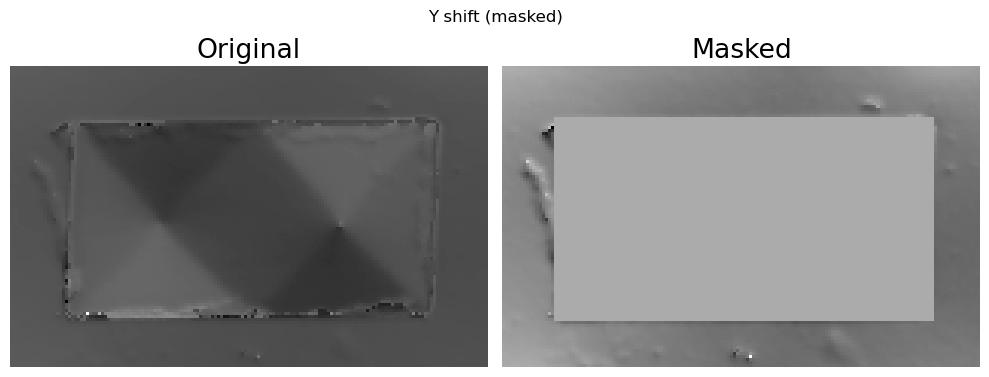

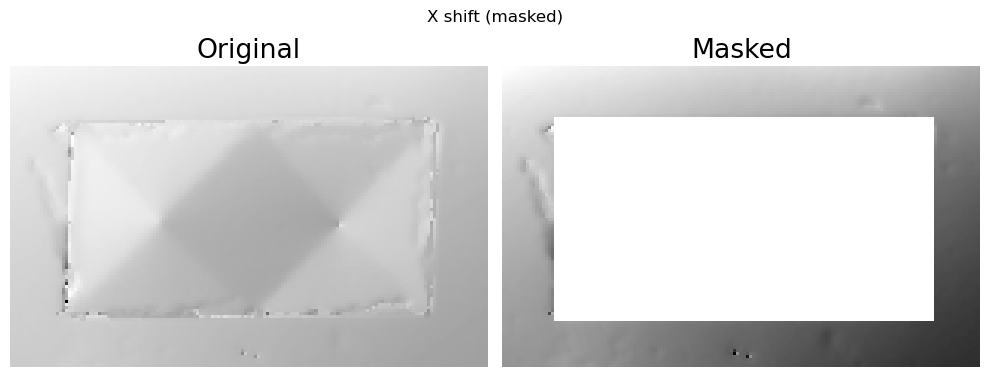

Fitted plane for Y shift: z = -0.012878x + -0.008890y + -1.686
Fitted plane for X shift: z = -0.075813x + -0.146134y + -0.213
[np.float64(-0.012878416537833011), np.float64(-0.008889873811598246), np.float64(-0.07581298467356809), np.float64(-0.14613429792891863)]


In [48]:
def rectangular_mask(
    image_shape,
    top_left,
    bottom_right,
):
    """
    Create a boolean mask for an image of size (H, W).

    Args:
        image_shape: tuple (H, W)
        top_left: (row1, col1)
        bottom_right: (row2, col2)

    Returns:
        mask (H, W) of dtype=bool
    """
    H, W = image_shape
    r1, c1 = top_left
    r2, c2 = bottom_right

    # Validate bounds (NumPy slicing semantics: end index is exclusive)
    if not (0 <= r1 < H and 0 <= r2 <= H and 0 <= c1 < W and 0 <= c2 <= W):
        raise ValueError("Rectangle coordinates are out of image bounds.")
    if not (r1 < r2 and c1 < c2):
        raise ValueError("top_left must be strictly above-left of bottom_right (r1<r2, c1<c2).")

    mask = np.zeros((H, W), dtype=bool)

    # Keep everything outside the rectangle
    mask[:] = True
    mask[r1:r2, c1:c2] = False

    return mask


def circular_mask(
    image_shape,
    center=None,
    radius=None,
):
    """
    Create a circular mask.

    Args:
        image_shape: (H, W)
        center: (cx, cy) in pixel coordinates (x=columns, y=rows).
                Defaults to image center.
        radius: circle radius. Defaults to largest that fits within the image.

    Returns:
        mask (H, W) of dtype=bool
    """
    H, W = image_shape

    if center is None:
        center = (W // 2, H // 2)  # (cx, cy)

    cx, cy = center
    if radius is None:
        # Max radius that fits inside image bounds
        radius = min(cx, cy, W - cx, H - cy)

    # Build grid: X varies along columns (width), Y varies along rows (height)
    Y, X = np.ogrid[:H, :W]
    dist_sq = (X - cx) ** 2 + (Y - cy) ** 2

    mask = dist_sq > radius ** 2

    return mask


def apply_mask(image, mask, fill_value=0):
    """
    Apply a boolean mask to an image.

    Args:
        image: (H, W) or (H, W, C)
        mask: (H, W) boolean mask where True means 'keep'.
        fill_value: value to write where mask == False.

    Returns:
        masked_img: same shape as image
    """
    if mask.shape != image.shape[:2]:
        raise ValueError("Mask spatial shape must match image height/width.")
    return np.where(mask, image, fill_value)


def fit_plane(masked_img, valid_mask=None):
    """
    Fit z = a*x + b*y + c on valid pixels using least squares.

    Args:
        masked_img: (H, W) numeric array
        valid_mask: (H, W) boolean mask indicating which pixels to use for fitting.
                    If None, uses masked_img != 0 and not NaN.
        
    Returns:
        (a, b, c) or (a, b, c, residuals, rank, s)
    """
    if masked_img.ndim != 2:
        raise ValueError("fit_plane expects a 2D image (H, W).")

    H, W = masked_img.shape

    # Define valid points if not provided
    if valid_mask is None:
        valid_mask = (masked_img != 0) & ~np.isnan(masked_img)

    ys, xs = np.nonzero(valid_mask)  # rows (y), cols (x)
    if ys.size < 3:
        raise ValueError("Need at least 3 valid pixels to fit a plane.")

    z = masked_img[ys, xs].astype(float)

    # Build least-squares matrix: [x, y, 1]
    A = np.c_[xs, ys, np.ones(xs.size)]
    coeffs, residuals, rank, s = np.linalg.lstsq(A, z, rcond=None)
    a, b, c = coeffs

    return a, b, c


def show_masked(original, masked, title=None):
    """
    Visualize original vs masked image side-by-side.
    """
    fig, axs = plt.subplots(1, 2, figsize=(10, 4))
    axs[0].imshow(original, cmap='gray')
    axs[0].set_title("Original")
    axs[1].imshow(masked, cmap='gray')
    axs[1].set_title("Masked")
    for ax in axs:
        ax.axis('off')
    if title:
        fig.suptitle(title)
    plt.tight_layout()
    plt.show()


def compute_descan_rect(shift_map, rect_top_left, rect_bottom_right, visualize=False):
    
    if shift_map.ndim != 3 or shift_map.shape[2] < 2:
        raise ValueError("shift_map must be (H, W, 2) with Y, X channels.")

    H, W, _ = shift_map.shape
    mask_rect = rectangular_mask((H, W), rect_top_left, rect_bottom_right)

    # Channel 0: Y; Channel 1: X
    masked_y = apply_mask(shift_map[:, :, 0], mask_rect, fill_value=0)
    masked_x = apply_mask(shift_map[:, :, 1], mask_rect, fill_value=0)

    if visualize:
        show_masked(shift_map[:, :, 0], masked_y, title="Y shift (masked)")
        show_masked(shift_map[:, :, 1], masked_x, title="X shift (masked)")

    a_y, b_y, c_y = fit_plane(masked_y)
    a_x, b_x, c_x = fit_plane(masked_x)

    print(f"Fitted plane for Y shift: z = {a_y:.6f}x + {b_y:.6f}y + {c_y:.3f}")
    print(f"Fitted plane for X shift: z = {a_x:.6f}x + {b_x:.6f}y + {c_x:.3f}")

    return [a_y, b_y, a_x, b_x]
    
def compute_descan_disk(shift_map, disk_center, disk_radius, visualize=False):
    
    if shift_map.ndim != 3 or shift_map.shape[2] < 2:
        raise ValueError("shift_map must be (H, W, 2) with Y, X channels.")

    H, W, _ = shift_map.shape
    mask_disk = circular_mask((H, W), disk_center, disk_radius)

    # Channel 0: Y; Channel 1: X
    masked_y = apply_mask(shift_map[:, :, 0], mask_disk, fill_value=0)
    masked_x = apply_mask(shift_map[:, :, 1], mask_disk, fill_value=0)

    if visualize:
        show_masked(shift_map[:, :, 0], masked_y, title="Y shift (masked)")
        show_masked(shift_map[:, :, 1], masked_x, title="X shift (masked)")

    a_y, b_y, c_y = fit_plane(masked_y)
    a_x, b_x, c_x = fit_plane(masked_x)

    print(f"Fitted plane for Y shift: z = {a_y:.6f}x + {b_y:.6f}y + {c_y:.3f}")
    print(f"Fitted plane for X shift: z = {a_x:.6f}x + {b_x:.6f}y + {c_x:.3f}")

    return [a_y, b_y, a_x, b_x]


if sample_name == '_rectangle':
    # Define rectangle coordinates (obtained by looking at image)
    top_left = (17, 17)       # (row, col)
    bottom_right = (84, 142)  # (row, col), end is exclusive

    descan_cal = compute_descan_rect(
        shift_map,
        rect_top_left=top_left,
        rect_bottom_right=bottom_right,
        visualize=True
    )
    print(descan_cal)

elif sample_name == '_disk':
    # Define circular coordinates (obtained by looking at image)
    center = (68,70)
    radius = 46

    descan_cal = compute_descan_disk(
        shift_map,
        disk_center=center,
        disk_radius=radius,
        visualize=True
    )
    print(descan_cal)


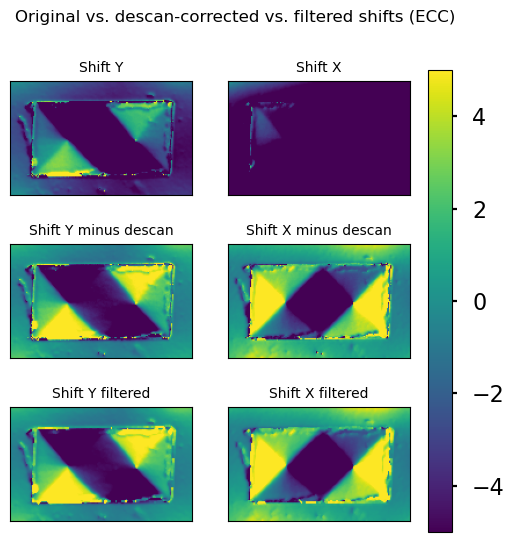

In [49]:
# Apply descan correction to the shift map
shift_map_sub = np.zeros(shift_map.shape)
shift_map_sub[:,:,0] = shift_map[:,:,0] - (descan_cal[0]*Rx + descan_cal[1]*Ry)
shift_map_sub[:,:,1] = shift_map[:,:,1] - (descan_cal[2]*Rx + descan_cal[3]*Ry)
shift_map_sub -= np.mean(shift_map_sub[10:90,0:5,:],axis=(0,1))

# Filter image (median chosen because of salt-and-pepper noise; Gaussian also possible)

#shift_map_filtered = filters.gaussian(shift_map_sub.astype(float), sigma=0.5)
shift_map_filtered = filters.median(shift_map_sub.astype(float), footprint=np.ones((2,2,1)))
#shift_map_filtered = gaussian_filter(shift_map_sub.astype(float), sigma=0.5)
#shift_map_filtered = median_filter(shift_map_sub.astype(float), footprint=np.ones((1,1,1)))

im_disp_list = [shift_map[:,:,0],shift_map[:,:,1],shift_map_sub[:,:,0],shift_map_sub[:,:,1],shift_map_filtered[:,:,0],shift_map_filtered[:,:,1]]
title_list = ['Shift Y','Shift X','Shift Y minus descan','Shift X minus descan','Shift Y filtered','Shift X filtered']

fig, axes = plt.subplots(3, 2, figsize=(6, 6))
axes = axes.flatten()

clim = 5
for i_plot in range(6):
    im = axes[i_plot].imshow(im_disp_list[i_plot], cmap='viridis', vmin=-clim, vmax=clim)
    axes[i_plot].set_xticks([])
    axes[i_plot].set_yticks([])
    axes[i_plot].set_title(title_list[i_plot], fontsize=10)

fig.suptitle(f"Original vs. descan-corrected vs. filtered shifts ({analysis_tag})")
cbar = fig.colorbar(im, ax=axes, location='right', fraction=0.1, pad=0.04)

plt.savefig(f"output/{analysis_tag}{sample_shape}_shift_descan_correction_filtered.png", bbox_inches='tight', dpi=300)

### Compute and show phase gradients

In [50]:
shift_map_rot = np.zeros(shift_map.shape)
for ind_line in range(R_Ny):
    shift_map_rot[ind_line] = dpc4d.process.rotate_coord_list(shift_map_filtered[ind_line],rot_theta)

defl_map = shift_map_rot*urad_per_px #urad
phase_grad_map = dpc4d.process.convert_defl_to_phase_grad(lamb_elec,defl_map*1e-6)

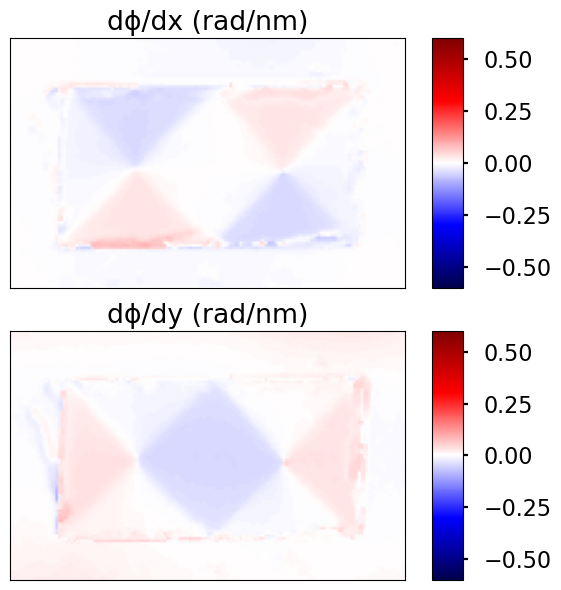

In [51]:
titles_diff = ['dϕ/dx (rad/nm)','dϕ/dy (rad/nm)']

dpc4d.visualize.plot_diff_maps([phase_grad_map[:,:,0],phase_grad_map[:,:,1]],titles_diff, 6, 6, clim=(-0.6,0.6))

plt.savefig('output/'+analysis_tag+sample_shape+'_phase_grad_map.png')

### Compute magnetic induction

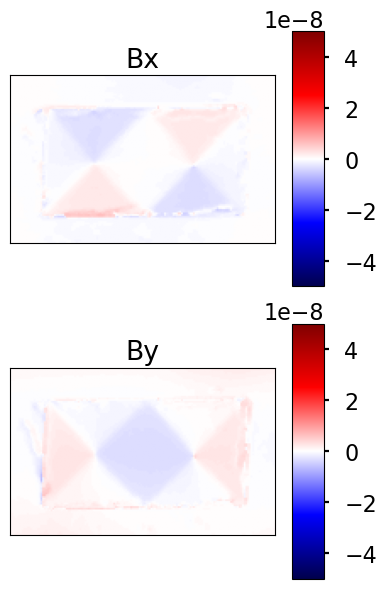

In [52]:
h = 6.626e-34      # Planck's constant
e = -1.602e-19     # charge of electron
t = 18e-9          # thickness of sample

Bx = -h*phase_grad_map[:,:,0]/(e*np.pi*t)
By = -h*phase_grad_map[:,:,1]/(e*np.pi*t)

titles_diff = ['Bx','By']

dpc4d.visualize.plot_diff_maps([Bx,By],titles_diff, 4, 6, clim=(-5e-8,5e-8))

plt.savefig('output/'+analysis_tag+sample_shape+'_magnetic_induction_map_components.png')

Colorcet not installed, proceeding with hsv from mpl
Saving: output/ECC_rect_magnetic_induction_map.png


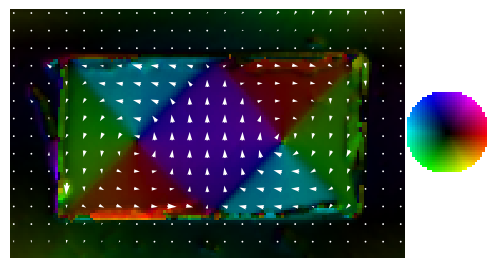

In [53]:
from PyLorentz.visualize import show_2D

show_2D(
    Bx*1e10,
    By*1e10,
    num_arrows=15,
    arrow_size=0.1,
    arrow_width=0.8,
    cmap='hsv',
    save='output/'+analysis_tag+sample_shape+'_magnetic_induction_map.png')